# Advanced Method Development - Task 2: Robustness to Image Degradation
This notebook evaluates how the trained ConvNeXt V2 model behaves when test images are degraded in ways that occur in practice.

We implement and test **4 types of degradations**:
1. **Additive Gaussian Noise**
2. **Gaussian Blur**
3. **Motion Blur**
4. **JPEG Compression**

We evaluate the model across **5 severity levels (0 = None, 1 = Mild, ..., 4 = Severe)** and plot performance-versus-severity curves showing Top-1 Accuracy and Macro-averaged F1 Score.

In [13]:
import os
import io
import torch
import numpy as np
import pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
from transformers import AutoImageProcessor, AutoModelForImageClassification
from sklearn.metrics import accuracy_score, f1_score

# Check device
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [14]:
# Load Model and Processor
model_path = "./model"
print("Loading model from:", model_path)
processor = AutoImageProcessor.from_pretrained(model_path)
model = AutoModelForImageClassification.from_pretrained(model_path).to(device)
model.eval()
print("Model loaded successfully!")

Loading model from: ./model


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 8175.55it/s]

Model loaded successfully!


## 1. Define Image Degradation Functions

In [15]:
def apply_gaussian_noise(image, severity):
    if severity == 0:
        return image
    # Standard deviation scales from 0.05 to 0.20
    std = severity * 0.05
    img_np = np.array(image).astype(np.float32) / 255.0
    noise = np.random.normal(0, std, img_np.shape)
    noisy = img_np + noise
    noisy = np.clip(noisy, 0.0, 1.0)
    return Image.fromarray(np.uint8(255 * noisy))

def apply_gaussian_blur(image, severity):
    if severity == 0:
        return image
    # Radius scales from 1.0 to 4.0
    radius = severity * 1.0
    return image.filter(ImageFilter.GaussianBlur(radius))

def apply_motion_blur(image, severity):
    if severity == 0:
        return image
    # Kernel length scales from 5 to 17 pixels
    length = severity * 4 + 1
    
    # Create a diagonal motion blur kernel
    kernel = np.zeros((length, length), dtype=np.float32)
    np.fill_diagonal(kernel, 1.0)
    kernel = kernel / np.sum(kernel)
    
    # Apply convolution using PyTorch for efficiency
    img_tensor = torch.tensor(np.array(image).transpose(2, 0, 1)).unsqueeze(0).float() / 255.0
    channels = img_tensor.shape[1]
    kernel_tensor = torch.tensor(kernel).unsqueeze(0).unsqueeze(0).repeat(channels, 1, 1, 1)
    
    padding = length // 2
    blurred_tensor = F.conv2d(img_tensor, kernel_tensor, padding=padding, groups=channels)
    
    blurred_np = blurred_tensor.squeeze(0).numpy().transpose(1, 2, 0)
    blurred_np = np.clip(blurred_np, 0.0, 1.0)
    return Image.fromarray(np.uint8(255 * blurred_np))

def apply_jpeg_compression(image, severity):
    if severity == 0:
        return image
    # Map severity to JPEG quality setting (lower is more compressed)
    quality_map = {1: 50, 2: 25, 3: 10, 4: 5}
    quality = quality_map[severity]
    
    buffer = io.BytesIO()
    image.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    return Image.open(buffer)

## 2. Visualize Degradation Examples
An example of a test image under all 4 degradations at Severity Level 3.

Saved degradation examples to: ../report/image/robustness_analysis/degradation_examples.png


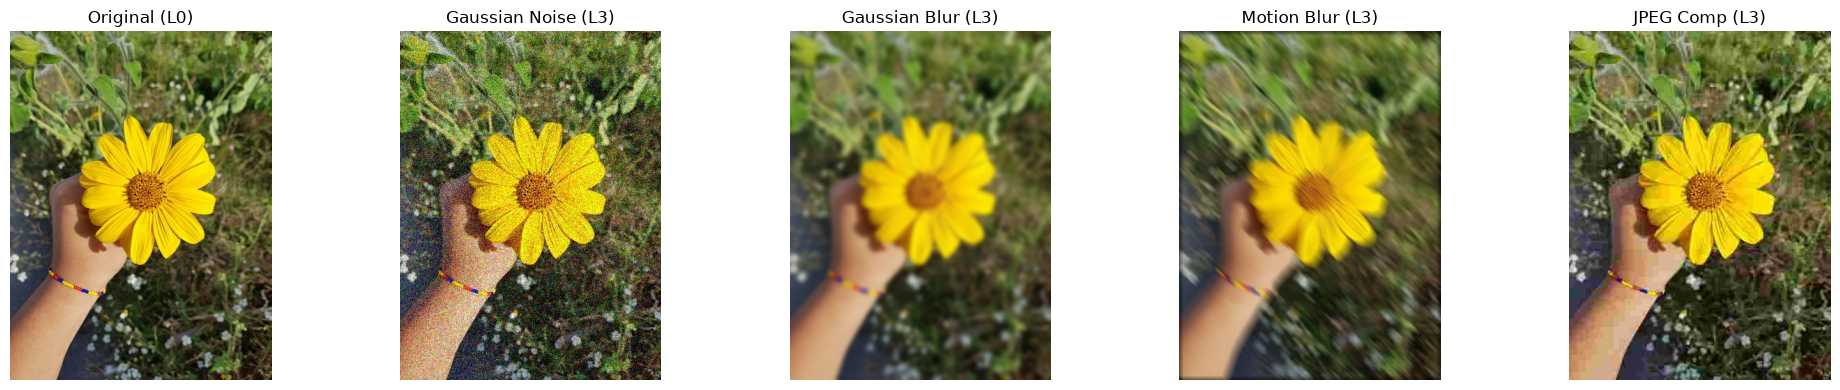

In [16]:
test_dir = "./data/test_select"

# Find any image
example_path = None
for root, dirs, files in os.walk(test_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            example_path = os.path.join(root, file)
            break
    if example_path:
        break

if example_path:
    img = Image.open(example_path).convert("RGB")
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    
    axes[0].imshow(img)
    axes[0].set_title("Original (L0)")
    axes[0].axis("off")
    
    axes[1].imshow(apply_gaussian_noise(img, 3))
    axes[1].set_title("Gaussian Noise (L3)")
    axes[1].axis("off")
    
    axes[2].imshow(apply_gaussian_blur(img, 3))
    axes[2].set_title("Gaussian Blur (L3)")
    axes[2].axis("off")
    
    axes[3].imshow(apply_motion_blur(img, 3))
    axes[3].set_title("Motion Blur (L3)")
    axes[3].axis("off")
    
    axes[4].imshow(apply_jpeg_compression(img, 3))
    axes[4].set_title("JPEG Comp (L3)")
    axes[4].axis("off")
    
    plt.tight_layout()
    out_dir = "../report/image/robustness_analysis"
    os.makedirs(out_dir, exist_ok=True)
    save_path = os.path.join(out_dir, "degradation_examples.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight", pad_inches=0.02)
    print(f"Saved degradation examples to: {save_path}")
    plt.show()
else:
    print("No test image found.")

## 3. Data Sampling & Evaluation Loop
We sample 1 image per class (1000 images total). Can use a smaller subset (`subset_size`) to speed up computation.

In [17]:
def sample_test_images(test_dir, num_samples_per_class=1):
    sampled_images = []
    for folder in sorted(os.listdir(test_dir)):
        folder_path = os.path.join(test_dir, folder)
        if os.path.isdir(folder_path):
            files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            if files:
                chosen_files = np.random.choice(files, min(len(files), num_samples_per_class), replace=False)
                for f in chosen_files:
                    sampled_images.append((os.path.join(folder_path, f), folder))
    return sampled_images

# Sample 1 image per class
all_sampled = sample_test_images(test_dir, num_samples_per_class=1)
print(f"Total sampled images (1 per class): {len(all_sampled)}")

# Set a subset size for speed (e.g. 200 images, 1 out of 5 classes)
subset_size = 200 
np.random.seed(42)
subset_indices = np.random.choice(len(all_sampled), subset_size, replace=False)
eval_samples = all_sampled
# eval_samples = [all_sampled[i] for i in subset_indices]
print(f"Using subset of {len(eval_samples)} images for fast evaluation sweep.")

Total sampled images (1 per class): 1000
Using subset of 1000 images for fast evaluation sweep.


In [ ]:
def evaluate_model(samples, degradation_func, severity):
    y_true = []
    y_pred = []
    label2id = model.config.label2id
    
    for img_path, true_label in samples:
        # Load and degrade
        img = Image.open(img_path).convert("RGB")
        degraded_img = degradation_func(img, severity)
        
        # Preprocess and predict
        inputs = processor(images=degraded_img, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            pred_idx = outputs.logits.argmax(-1).item()
            
        y_pred.append(pred_idx)
        
        # Map true label string to its index
        if true_label in label2id:
            y_true.append(int(label2id[true_label]))
        else:
            y_true.append(-1)
            
                
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return accuracy, f1

In [19]:
def run_sweep(samples):
    degradations = {
        "Gaussian Noise": apply_gaussian_noise,
        "Gaussian Blur": apply_gaussian_blur,
        "Motion Blur": apply_motion_blur,
        "JPEG Compression": apply_jpeg_compression
    }
    
    severities = [0, 1, 2, 3, 4]
    results = []
    
    for deg_name, deg_func in degradations.items():
        print(f"\nEvaluating {deg_name}...")
        for sev in severities:
            acc, f1 = evaluate_model(samples, deg_func, sev)
            print(f"  Severity {sev} | Accuracy: {acc:.4f} | Macro F1: {f1:.4f}")
            results.append({
                "Degradation": deg_name,
                "Severity": sev,
                "Accuracy": acc,
                "Macro_F1": f1
            })
            
    return pd.DataFrame(results)

## 4. Run the Robustness Sweep

In [20]:
df_results = run_sweep(eval_samples)


Evaluating Gaussian Noise...
  Severity 0 | Accuracy: 0.7780 | Macro F1: 0.7301
  Severity 1 | Accuracy: 0.7380 | Macro F1: 0.6789
  Severity 2 | Accuracy: 0.6700 | Macro F1: 0.6010
  Severity 3 | Accuracy: 0.5960 | Macro F1: 0.5247
  Severity 4 | Accuracy: 0.5070 | Macro F1: 0.4343

Evaluating Gaussian Blur...
  Severity 0 | Accuracy: 0.7780 | Macro F1: 0.7301
  Severity 1 | Accuracy: 0.7500 | Macro F1: 0.6927
  Severity 2 | Accuracy: 0.6300 | Macro F1: 0.5609
  Severity 3 | Accuracy: 0.4930 | Macro F1: 0.4203
  Severity 4 | Accuracy: 0.3500 | Macro F1: 0.2867

Evaluating Motion Blur...
  Severity 0 | Accuracy: 0.7780 | Macro F1: 0.7301
  Severity 1 | Accuracy: 0.7000 | Macro F1: 0.6375
  Severity 2 | Accuracy: 0.5200 | Macro F1: 0.4484
  Severity 3 | Accuracy: 0.3820 | Macro F1: 0.3153


/var/folders/lj/6clpcbqs4pxftvwt9s09ywh40000gn/T/ipykernel_33471/75026884.py:40: RuntimeWarning: invalid value encountered in cast
  return Image.fromarray(np.uint8(255 * blurred_np))


  Severity 4 | Accuracy: 0.2680 | Macro F1: 0.2125

Evaluating JPEG Compression...
  Severity 0 | Accuracy: 0.7780 | Macro F1: 0.7301
  Severity 1 | Accuracy: 0.7600 | Macro F1: 0.7074
  Severity 2 | Accuracy: 0.7300 | Macro F1: 0.6764
  Severity 3 | Accuracy: 0.6450 | Macro F1: 0.5795
  Severity 4 | Accuracy: 0.4310 | Macro F1: 0.3662


## 5. Plot Performance-versus-Severity Curves

Saved robustness curves to: ../report/image/robustness_analysis/robustness_curves.png


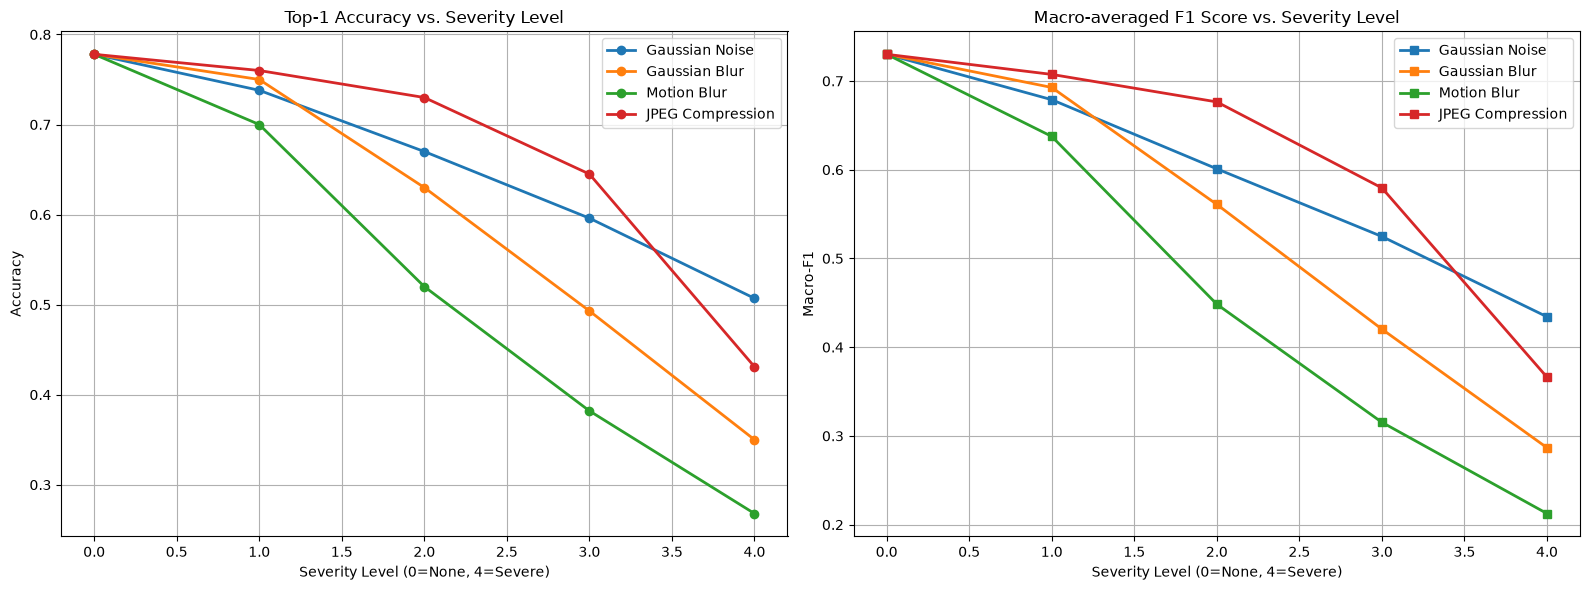

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Accuracy
for deg_name in df_results["Degradation"].unique():
    sub = df_results[df_results["Degradation"] == deg_name]
    axes[0].plot(sub["Severity"], sub["Accuracy"], marker='o', label=deg_name, linewidth=2)
axes[0].set_title("Top-1 Accuracy vs. Severity Level")
axes[0].set_xlabel("Severity Level (0=None, 4=Severe)")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True)
axes[0].legend()

# Plot Macro F1
for deg_name in df_results["Degradation"].unique():
    sub = df_results[df_results["Degradation"] == deg_name]
    axes[1].plot(sub["Severity"], sub["Macro_F1"], marker='s', label=deg_name, linewidth=2)
axes[1].set_title("Macro-averaged F1 Score vs. Severity Level")
axes[1].set_xlabel("Severity Level (0=None, 4=Severe)")
axes[1].set_ylabel("Macro-F1")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
out_dir = "../report/image/robustness_analysis"
os.makedirs(out_dir, exist_ok=True)
save_path = os.path.join(out_dir, "robustness_curves.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight", pad_inches=0.02)
print(f"Saved robustness curves to: {save_path}")
plt.show()
